# Exploration du dataset de Clara

Inventaire des fichiers, contrôle initial sur **100 images** (graine 42),
affichage des exemples, puis vérification des 1 506 images.
Les fichiers d'origine sont conservés. Les étiquettes sont celles des dossiers,
conformément au descriptif fourni ; elles ne sont pas validées médicalement ici.

In [1]:
"""Exploration d'un dossier d'images, sans modification des originaux."""

from pathlib import Path
import hashlib
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps


EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp", ".gif"}
from IPython.display import display, Markdown

In [2]:
def inventory(data_dir):
    root = Path(data_dir).expanduser().resolve()
    if not root.is_dir():
        raise FileNotFoundError(f"Dossier du dataset introuvable : {root}")
    records = []
    for path in sorted(root.rglob("*")):
        if path.is_file() and not path.is_symlink():
            relative = path.relative_to(root)
            records.append({
                "path": relative.as_posix(),
                "folder": relative.parent.as_posix(),
                "extension": path.suffix.lower(),
                "bytes": path.stat().st_size,
                "image_candidate": path.suffix.lower() in EXTENSIONS,
            })
    return pd.DataFrame(records, columns=[
        "path", "folder", "extension", "bytes", "image_candidate"
    ])

In [3]:
def inspect_sample(data_dir, files, sample_size=100, seed=42):
    """Contrôle complet du décodage de la première image de chaque fichier choisi."""
    if sample_size < 1:
        raise ValueError("sample_size doit être strictement positif.")
    root = Path(data_dir).expanduser().resolve()
    candidates = files.loc[files.image_candidate, "path"].tolist()
    if not candidates:
        raise ValueError("Aucune image reconnue. Vérifier le chemin et les extensions du dataset.")
    selected = random.Random(seed).sample(candidates, min(sample_size, len(candidates)))
    records = []
    for relative in selected:
        record = {"path": relative, "error": "", "warnings": ""}
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                with Image.open(root / relative) as original:
                    record.update(
                        format=original.format, width=original.width,
                        height=original.height, mode=original.mode,
                        channels=len(original.getbands()),
                        bands=",".join(original.getbands()),
                        frames=getattr(original, "n_frames", 1),
                    )
                    original.verify()
                with Image.open(root / relative) as original:
                    original.load()
                    pixels = np.asarray(original)
                    record["pixel_sha256"] = hashlib.sha256(
                        f"{original.mode}:{original.size}:".encode() + pixels.tobytes()
                    ).hexdigest()
                    record["rgb_channels_equal"] = (
                        bool(np.array_equal(pixels[:, :, 0], pixels[:, :, 1])
                             and np.array_equal(pixels[:, :, 1], pixels[:, :, 2]))
                        if original.mode == "RGB" else None
                    )
                    oriented = ImageOps.exif_transpose(original)
                    record.update(display_width=oriented.width, display_height=oriented.height)
                    # Mesures indicatives sur une miniature en niveaux de gris.
                    preview = oriented.convert("RGB")
                    preview.thumbnail((256, 256))
                    gray = np.asarray(preview.convert("L"), dtype=np.float32)
                    record.update(gray_mean=float(gray.mean()), gray_std=float(gray.std()))
                record["warnings"] = " | ".join(str(w.message) for w in caught)
        except Exception as exc:
            record["error"] = f"{type(exc).__name__}: {exc}"
        records.append(record)
    return pd.DataFrame(records)

In [4]:
def show_examples(data_dir, inspected, count=12):
    valid = inspected.loc[inspected.error.eq("")].head(count)
    if valid.empty:
        raise ValueError("Aucune image lisible à afficher dans l'échantillon.")
    columns = min(4, len(valid))
    rows = (len(valid) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 3.5 * rows), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, (_, record) in zip(axes.flat, valid.iterrows()):
        with Image.open(Path(data_dir) / record.path) as original:
            preview = ImageOps.exif_transpose(original).convert("RGB")
            preview.thumbnail((512, 512))
            ax.imshow(preview)
        ax.set_title(
            f"{Path(record.path).name[:35]}\n"
            f"{int(record.width)} × {int(record.height)} px · {record['mode']}",
            fontsize=9,
        )
    fig.suptitle("Exemples du dataset — proportions conservées", fontsize=14)
    fig.tight_layout()
    return fig

In [5]:
DATA_DIR = Path("mri_dataset_brain_cancer_oc")
SAMPLE_SIZE = 100
SEED = 42
for description in DATA_DIR.glob("*.txt"):
    print(description.read_text(encoding="utf-8"))

Description

Ce jeu de données comprend un total de 1500 images :

    1400 images non étiquetées

    100 images étiquetées

Les images étiquetées sont réparties en deux catégories :

    Normal : Images de cerveaux sains.

    Cancer : Images de cerveaux présentant des signes de tumeurs.

Caractéristiques des Images

Toutes les images ont été redimensionnées à une taille standardisée de 512×512 pixels. Cette standardisation assure leur compatibilité avec divers pipelines de traitement d'images et d'apprentissage automatique. Elles sont enregistrées au format d'image courant JPEG (.jpg).
Applications Potentielles

Ce jeu de données peut être exploité pour un large éventail d'applications, notamment :

    🤖 L'entraînement et l'évaluation de divers modèles d'apprentissage profond (par exemple, DenseNet201, YOLOv8x/s, CNN, ResNet50v2, VGG-16, MobileNetV2).

    🔬 Le développement d'algorithmes de classification d'images pour la détection et la classification des tumeurs cérébrales.

   

## 1. Structure et effectifs
Les comptes portent sur tous les fichiers du dossier.

In [6]:
files = inventory(DATA_DIR)
images = files.loc[files.image_candidate].copy()
counts = images.groupby("folder").size().rename("images")
display(counts.to_frame())
display(files.groupby("extension").agg(fichiers=("path", "size"), octets=("bytes", "sum")))
print(f"Total : {len(images)} images ; {files.bytes.sum() / 1024**2:.2f} Mio, documentation comprise.")
print("Écart au descriptif : 1506 images observées contre 1500 annoncées ; 1406 sans label contre 1400.")

,images
folder,
avec_labels/cancer,50
avec_labels/normal,50
sans_label,1406


,fichiers,octets
extension,,
.jpg,1506,37272490
.txt,1,1230


Total : 1506 images ; 35.55 Mio, documentation comprise.
Écart au descriptif : 1506 images observées contre 1500 annoncées ; 1406 sans label contre 1400.


## 2. Premier contrôle sur un échantillon réduit
Tirage aléatoire sans remise. Dimensions et modes relevés avant conversion d'affichage.

,,,,images
width,height,mode,channels,
512,512,RGB,3,100


Fichiers en erreur : 0 / 100


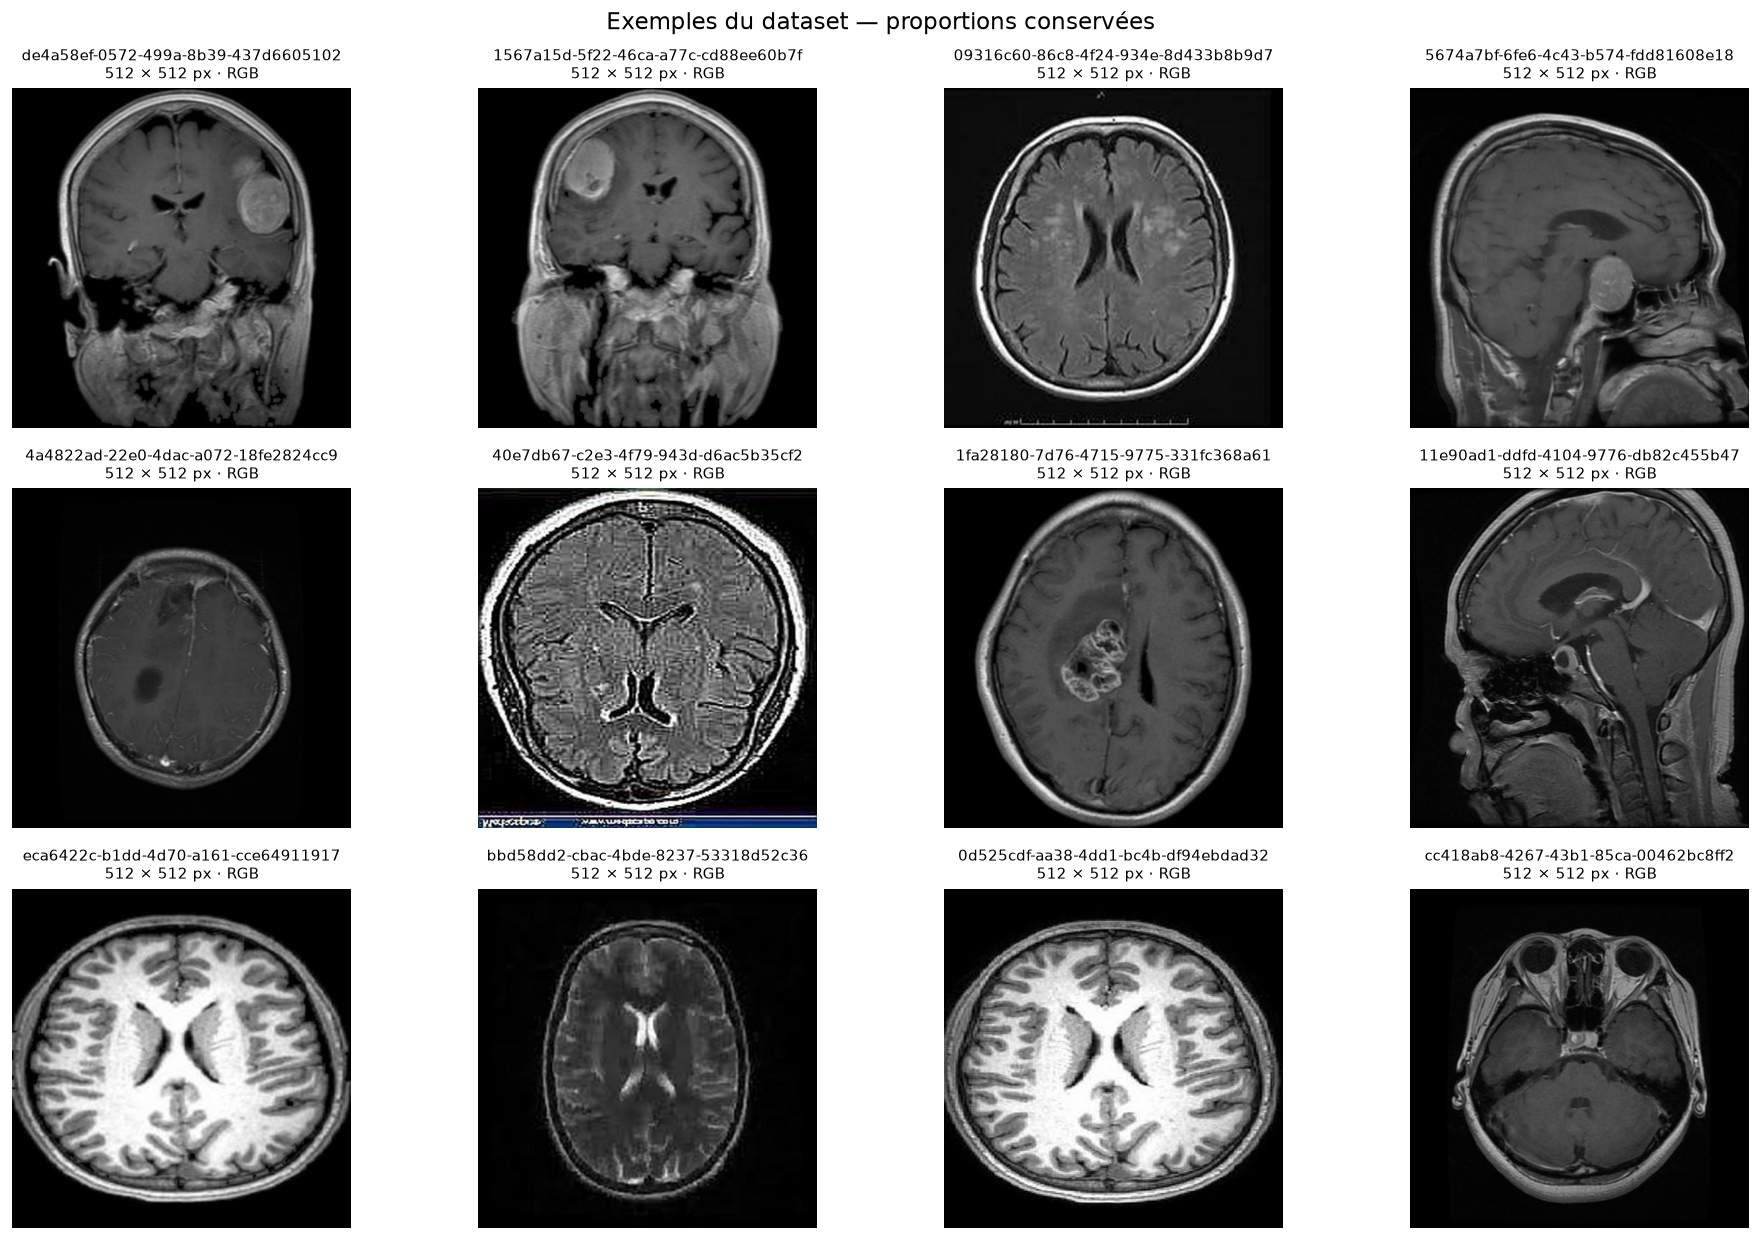

In [7]:
sample = inspect_sample(DATA_DIR, files, SAMPLE_SIZE, SEED)
display(sample.groupby(["width", "height", "mode", "channels"]).size().rename("images").to_frame())
print(f"Fichiers en erreur : {sample.error.ne('').sum()} / {len(sample)}")
figure = show_examples(DATA_DIR, sample)
display(figure)
plt.close(figure)

## 3. Contrôle complet
Décodage de chaque JPEG, contrôle des canaux RGB et empreinte SHA-256 des pixels décodés. Les doublons proches ou provenant du même patient ne sont pas identifiés par cette méthode.

In [8]:
checked = inspect_sample(DATA_DIR, files, len(images), SEED)
checked["folder"] = checked.path.map(lambda value: Path(value).parent.as_posix())
valid = checked.loc[checked.error.eq("")].copy()
errors = checked.loc[checked.error.ne("")]
duplicates = valid.loc[valid.duplicated("pixel_sha256", keep=False)].sort_values("pixel_sha256")
duplicate_groups = duplicates.groupby("pixel_sha256").agg(
    images=("path", "size"), dossiers=("folder", lambda values: " | ".join(sorted(set(values))))
)
display(valid.groupby(["width", "height", "mode", "channels"]).size().rename("images").to_frame())
display(valid.rgb_channels_equal.value_counts().rename_axis("R = G = B").to_frame("images"))
display(duplicate_groups.groupby("dossiers").agg(groupes=("images", "size"), images=("images", "sum")))
print(f"Erreurs : {len(errors)} ; avertissements : {checked.warnings.ne('').sum()}")
print(f"Doublons : {len(duplicate_groups)} groupes, {len(duplicates)} fichiers concernés, "
      f"{valid.pixel_sha256.duplicated().sum()} copies supplémentaires.")

,,,,images
width,height,mode,channels,
512,512,RGB,3,1506


,images
R = G = B,
True,1496
False,10


,groupes,images
dossiers,,
avec_labels/cancer | sans_label,8,16
avec_labels/normal | sans_label,23,48
sans_label,59,122


Erreurs : 0 ; avertissements : 0
Doublons : 90 groupes, 186 fichiers concernés, 96 copies supplémentaires.


## 4. Exemples par dossier
Quatre exemples par groupe, avec un tirage reproductible. Le nom de dossier décrit le label fourni.

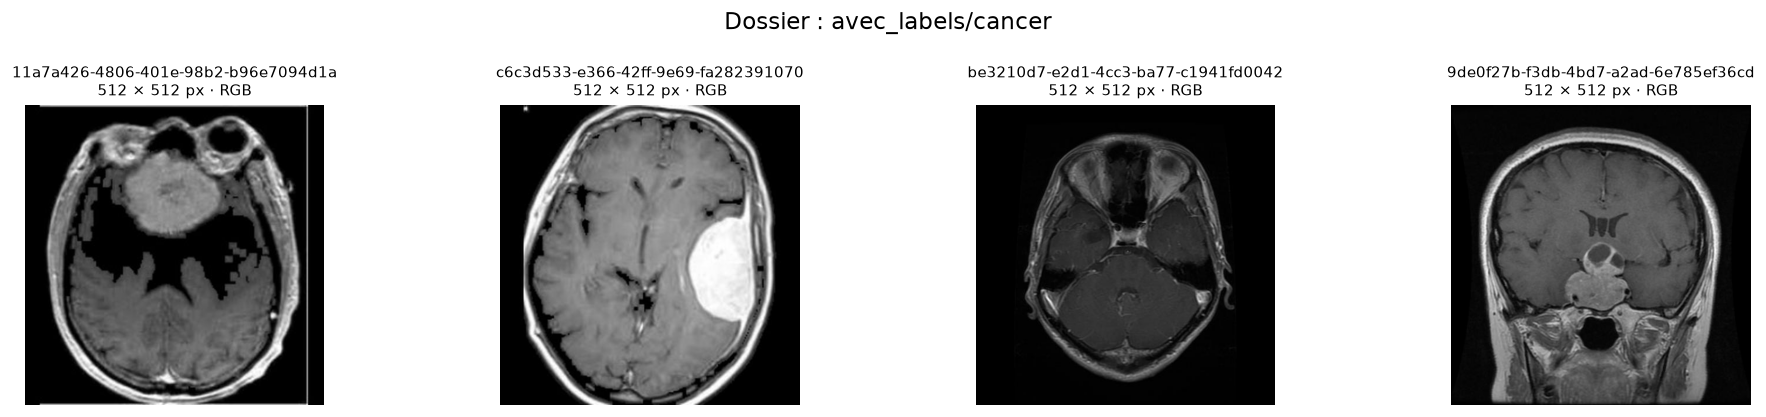

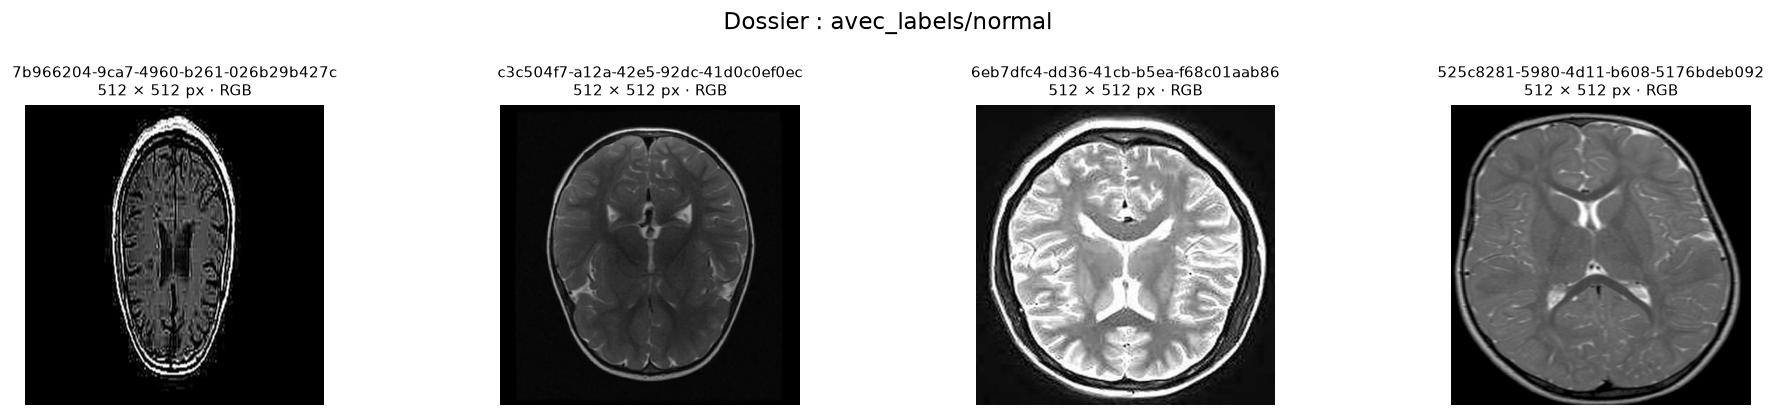

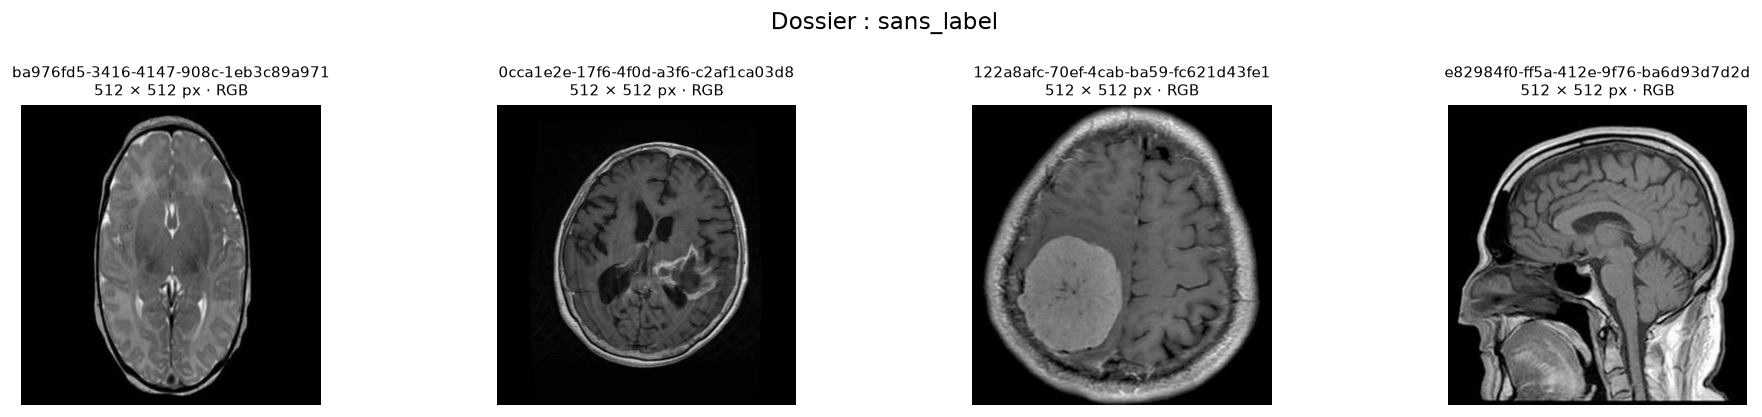

In [9]:
for folder, group in valid.groupby("folder"):
    selection = group.sample(n=min(4, len(group)), random_state=SEED)
    figure = show_examples(DATA_DIR, selection, count=4)
    figure.suptitle(f"Dossier : {folder}", fontsize=14)
    display(figure)
    plt.close(figure)

## 5. Vue d'ensemble des contrastes
Moyenne et écart-type des niveaux de gris sur des miniatures (0–255). Ces mesures décrivent le dataset sans décider quelles images conserver.

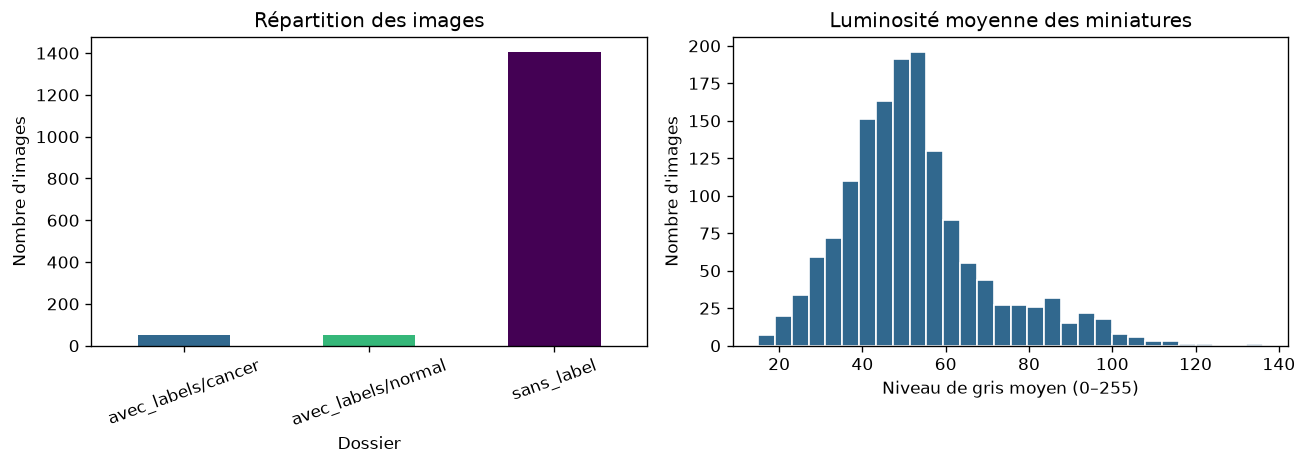

,gray_mean,gray_std
count,1506.00,1506.00
mean,52.40,48.75
std,17.38,13.61
min,14.95,20.76
25%,41.29,39.77
50%,50.27,44.92
75%,59.26,54.16
max,136.23,119.16


In [10]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
counts.plot.bar(ax=axes[0], color=["#31688e", "#35b779", "#440154"])
axes[0].set(title="Répartition des images", ylabel="Nombre d'images", xlabel="Dossier")
axes[0].tick_params(axis="x", rotation=20)
axes[1].hist(valid.gray_mean, bins=30, color="#31688e", edgecolor="white")
axes[1].set(title="Luminosité moyenne des miniatures", xlabel="Niveau de gris moyen (0–255)", ylabel="Nombre d'images")
figure.tight_layout()
display(figure)
plt.close(figure)
display(valid[["gray_mean", "gray_std"]].describe().round(2))

## 6. Observations visuelles et suite du travail

Les planches montrent des vues axiales, coronales et sagittales, des cadrages et
des tailles du cerveau variables à l'intérieur de l'image, ainsi que des contrastes
et une netteté hétérogènes. Certaines images comportent des inscriptions, des
échelles ou des bordures issues de captures. La résolution de stockage uniforme
ne garantit donc pas une qualité visuelle uniforme.

Ces constats concernent les exemples affichés. La justesse des labels n'est pas
évaluée par l'inspection technique. Aucune déduction de classe n'est appliquée
aux images sans label.

Avant l'apprentissage : examiner les doublons entre dossiers pour éviter de les
répartir entre entraînement et évaluation ; conserver une table de correspondance
avant tout nettoyage ; rechercher les identifiants de patients et la provenance
des images (absents des informations fournies). Examiner les inscriptions et les
bordures comme sources possibles de biais. Le traitement du contraste et le choix
RGB/niveaux de gris restent à définir selon le modèle.

In [11]:
report = f'''# Exploration du dataset de Clara

## Vue d'ensemble
- {len(images)} images JPEG : 50 cancer, 50 normal, 1406 sans label.
- 100 images étiquetées (6,64 %) ; équilibre 50/50 des deux classes fournies.
- Le descriptif annonce 1500 images : 6 images sans label supplémentaires sont présentes.
- Échantillon initial de {len(sample)} images ; contrôle technique ensuite étendu aux {len(checked)} images.
- {len(errors)} fichier illisible ; {checked.warnings.ne('').sum()} avertissement.
- Toutes les images contrôlées : 512 × 512 pixels, RGB, trois canaux, une seule frame.
- {int(valid.rgb_channels_equal.sum())} images ont R = G = B ; {int((~valid.rgb_channels_equal.astype(bool)).sum())} ont des canaux différents.
- {len(duplicate_groups)} groupes de pixels identiques : {len(duplicates)} fichiers concernés, {valid.pixel_sha256.duplicated().sum()} copies supplémentaires.
- 31 groupes de doublons relient des images étiquetées et non étiquetées (8 cancer, 23 normal).
- Aucun doublon exact observé entre les dossiers cancer et normal.

## Exploration visuelle
- Vues axiales, coronales et sagittales ; cadrages, contraste et netteté variables.
- Fonds noirs et place occupée par le cerveau variables ; inscriptions, échelles et bordures sur certains exemples.
- La taille standardisée ne garantit pas l'homogénéité visuelle.
- Les classes sont celles fournies dans les dossiers, sans validation médicale dans cette exploration.

## Points à traiter avant apprentissage
- Clarifier l'écart de six fichiers avec le descriptif.
- Gérer les doublons avant de constituer les ensembles d'entraînement et d'évaluation.
- Rechercher les identifiants patients pour construire les partitions à ce niveau si possible.
- Examiner les inscriptions et bordures, et choisir un prétraitement adapté au modèle.
- Les doublons proches, l'origine des images et la justesse des étiquettes restent à vérifier.

Aucun fichier source modifié ou supprimé. Les tableaux et les images sont inclus dans ce notebook.
'''
report = "\n".join(line.lstrip() for line in report.splitlines()) + "\n"
display(Markdown(report))

# Exploration du dataset de Clara

## Vue d'ensemble
- 1506 images JPEG : 50 cancer, 50 normal, 1406 sans label.
- 100 images étiquetées (6,64 %) ; équilibre 50/50 des deux classes fournies.
- Le descriptif annonce 1500 images : 6 images sans label supplémentaires sont présentes.
- Échantillon initial de 100 images ; contrôle technique ensuite étendu aux 1506 images.
- 0 fichier illisible ; 0 avertissement.
- Toutes les images contrôlées : 512 × 512 pixels, RGB, trois canaux, une seule frame.
- 1496 images ont R = G = B ; 10 ont des canaux différents.
- 90 groupes de pixels identiques : 186 fichiers concernés, 96 copies supplémentaires.
- 31 groupes de doublons relient des images étiquetées et non étiquetées (8 cancer, 23 normal).
- Aucun doublon exact observé entre les dossiers cancer et normal.

## Exploration visuelle
- Vues axiales, coronales et sagittales ; cadrages, contraste et netteté variables.
- Fonds noirs et place occupée par le cerveau variables ; inscriptions, échelles et bordures sur certains exemples.
- La taille standardisée ne garantit pas l'homogénéité visuelle.
- Les classes sont celles fournies dans les dossiers, sans validation médicale dans cette exploration.

## Points à traiter avant apprentissage
- Clarifier l'écart de six fichiers avec le descriptif.
- Gérer les doublons avant de constituer les ensembles d'entraînement et d'évaluation.
- Rechercher les identifiants patients pour construire les partitions à ce niveau si possible.
- Examiner les inscriptions et bordures, et choisir un prétraitement adapté au modèle.
- Les doublons proches, l'origine des images et la justesse des étiquettes restent à vérifier.

Aucun fichier source modifié ou supprimé. Les tableaux et les images sont inclus dans ce notebook.
